In [1]:
import geopandas as gpd
import gpxpy
import glob
import gpxpy.gpx
from shapely.geometry import LineString
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
import matplotlib.animation as animation
import numpy as np
from utils import *

In [2]:
colors = {'hubert': 'cornflowerblue',
          'pa': 'tomato'}

In [ ]:
import numpy as np
from scipy.spatial import KDTree

def calculate_track_density_and_mask(easting, northing, radius_meters, time_excl_window=10):
    """
    Calculates the passage density and a visibility mask for each point, 
    ensuring counts are aggregated onto the *first* point of a segment, 
    and subsequent passages are masked.

    :param easting: List or array of Easting coordinates (X).
    :param northing: List or array of Northing coordinates (Y).
    :param radius_meters: The spatial distance (in meters) for considering points as "same road".
    :param time_excl_window: The number of indices (points) before and after 
                             to exclude from the count.
    :return: A tuple (final_pass_counts, visibility_mask). 
    """
    if len(easting) != len(northing) or len(easting) == 0:
        return np.array([]), np.array([])

    points = np.column_stack((easting, northing))
    n_points = len(points)
    
    # --- 1. Build KD-Tree ---
    tree = KDTree(points)
    search_radius = radius_meters
    
    # --- 2. Initialize Outputs ---
    # We only need the final outputs, initialized to zero/True
    final_pass_counts = np.zeros(n_points, dtype=int)
    visibility_mask = np.ones(n_points, dtype=bool) 
    
    # --- 3. Single Pass Aggregation (Combines original Steps 3 & 4 logic) ---
    for i in range(n_points):
        # Only proceed if this point hasn't been masked by an earlier neighbor
        if not visibility_mask[i]:
            continue

        # If we reach here, point 'i' is the first point of its segment 
        # (or the first point of a new passage). It is VISIBLE.
        
        # Spatial Query: Find all point indices within the search_radius
        # Note: Includes point i itself.
        neighbor_indices = tree.query_ball_point(points[i], r=search_radius)
        
        # Initialize count with point 'i' itself (1 pass)
        count = 1
        
        # Check all subsequent neighbors (k > i)
        for k in neighbor_indices:
            
            # --- Condition for Re-Passage ---
            # 1. k must be later than i (k > i)
            # 2. k must be temporally distant from i (k - i > time_excl_window)
            
            if k > i and k - i > time_excl_window:
                # Point k is a subsequent, distant passage to the same location.
                
                # Check if point k was *already* claimed and masked by an earlier point j < i.
                # If visibility_mask[k] is already False, it means a point j (i < j < k)
                # already took the credit. We skip it to avoid double-counting.
                if visibility_mask[k]:
                    # This point 'k' is a valid re-visit that hasn't been claimed yet.
                    count += 1
                    
                    # MASK IT: Ensure this subsequent passage point 'k' is hidden.
                    visibility_mask[k] = False 
                    
        # Assign the total aggregated count to the *visible* representative point 'i'
        final_pass_counts[i] = count

    return final_pass_counts, visibility_mask

In [4]:
def static_plot_density_mask(
        track, longs_tot, lats_tot, counts, mask, user, fig, ax,
        x_min_global, x_max_global, y_min_global, y_max_global,
        step, round):

    x_min = min(longs_tot) - 500
    x_max = max(longs_tot) + 500
    y_min = min(lats_tot) - 500
    y_max = max(lats_tot) + 500

    if x_min_global > x_min:
        x_min_global = x_min
    if x_max_global < x_min:
        x_max_global = x_max
    if y_min_global > y_min:
        y_min_global = y_min
    if y_max_global < y_min:
        y_max_global = y_max

    ax.set_xlim(x_min_global, x_max_global)
    ax.set_ylim(y_min_global, y_max_global)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager)
    ax.set_axis_off()
    seg_start = 0
    # print(np.shape(mask))
    # print(np.shape(longs_tot))
    # print(np.shape(counts))
    for segment in track:
        lats_tot = np.array(segment['lats'][::step])
        longs_tot = np.array(segment['longs'][::step])
        seg_end = seg_start + len(lats_tot)
        # print(np.shape(lats_tot))
        # print(np.shape(mask[seg_start:seg_end]))
        lats_tot *= mask[seg_start:seg_end]
        longs_tot *= mask[seg_start:seg_end]
        ax.scatter(longs_tot, lats_tot,
                   c=counts[seg_start:seg_end], s=0.5, alpha=1,
                   cmap='Reds',
                   vmin=0, vmax=5,
                   marker='o')
        
        seg_start = seg_end
    fig.savefig(
        f'{user}_density_mask_step-{step}_round-{round}.png', dpi=500)
    return fig, ax, x_min_global, x_max_global, y_min_global, y_max_global


In [5]:
def plot_track_density_mask(users, step, radius_meters, time_excl_window):
    fig, ax = plt.subplots(figsize=(8, 8))
    x_min_global, x_max_global, y_min_global, y_max_global = \
        np.inf, -np.inf, np.inf, -np.inf
    for user in users:
        track, xs_tot, ys_tot = load_long_lat(user, n_segments=None)
        pass_counts, visibility_mask = calculate_track_density_and_mask(
            ys_tot[::step], xs_tot[::step], radius_meters, time_excl_window)
        fig, ax, x_min_global, x_max_global, y_min_global, y_max_global = \
            static_plot_density_mask(
                track, xs_tot, ys_tot, pass_counts, visibility_mask,
                user, fig, ax,
                x_min_global, x_max_global, y_min_global, y_max_global,
                step=step, round=5)
    plt.show()
    return xs_tot, ys_tot

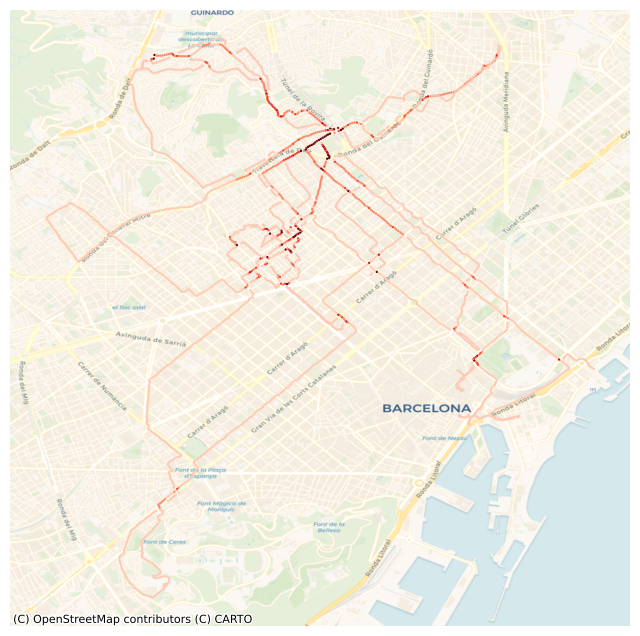

In [6]:
xs_tot, ys_tot = plot_track_density_mask(['hubert'], step=1, radius_meters=50, time_excl_window=100)

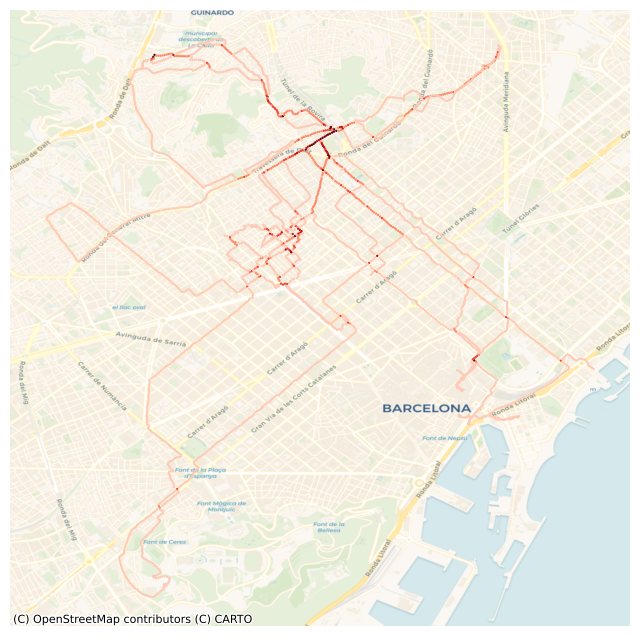

In [7]:
xs_tot, ys_tot = plot_track_density_mask(['hubert'], step=1, radius_meters=30, time_excl_window=100)

# Augmented version with the closer point path identification

In [ ]:
import numpy as np
from scipy.spatial import KDTree

def calculate_track_density_projected(easting, northing, radius_meters=5.0, time_excl_window=10):
    
    if len(easting) != len(northing) or len(easting) == 0:
        return np.array([]), np.array([]) # Return two arrays now

    points = np.column_stack((easting, northing))
    tree = KDTree(points)
    search_radius = radius_meters
    n_points = len(points)
    
    pass_counts = np.zeros(n_points, dtype=int)
    # New array: True if this point is the first time we've passed this area
    is_first_pass = np.ones(n_points, dtype=bool) 
    
    for i in range(n_points):
        # 1. Density Calculation (Unchanged)
        neighbor_indices = tree.query_ball_point(points[i], r=search_radius)
        
        min_idx = max(0, i - time_excl_window)
        max_idx = min(n_points - 1, i + time_excl_window)
        exclusion_set = set(range(min_idx, max_idx + 1))
        
        final_count = 0
        for neighbor_idx in neighbor_indices:
            if neighbor_idx not in exclusion_set:
                final_count += 1
        pass_counts[i] = final_count + 1

        # 2. Redundancy Check (NEW LOGIC)
        # Find ALL neighbors that occurred EARLIER in time (j < i).
        # We don't need to re-query the tree, we just check the neighbor indices:
        earlier_neighbors = [j for j in neighbor_indices if j < i]
        
        if earlier_neighbors:
            # If ANY point was found earlier in this area, the current point 'i'
            # is a subsequent pass and is redundant for plotting the unique path.
            is_first_pass[i] = False
        
    return pass_counts, is_first_pass

# Minimal version without the mask, working

In [65]:
pass_counts = calculate_track_density_projected(ys_tot, xs_tot, radius_meters=10.0, time_excl_window=3)


In [64]:
set(pass_counts)

{np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}

In [54]:
df_result

,latitude,longitude,time,pass_count
0,41.385105,2.173387,1970-01-01 00:00:00,2
1,41.385139,2.173449,1970-01-01 00:00:01,2
2,41.385187,2.173502,1970-01-01 00:00:02,2
3,41.385236,2.173531,1970-01-01 00:00:03,3
4,41.385258,2.173545,1970-01-01 00:00:04,3
...,...,...,...,...
495,41.385253,2.173558,1970-01-01 00:08:15,3
496,41.385222,2.173538,1970-01-01 00:08:16,3
497,41.385173,2.173487,1970-01-01 00:08:17,2
498,41.385134,2.173434,1970-01-01 00:08:18,2


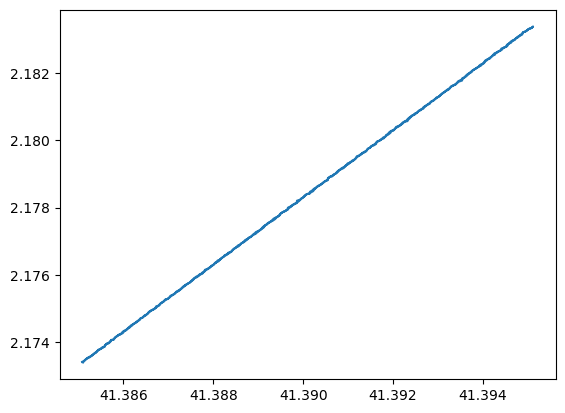

In [44]:
plt.plot(df_result['latitude'], df_result['longitude'])